# **Цель работы**
1. Изучить проблему высокой размерности данных и её влияние на анализ.
2. Освоить методы линейного и нелинейного снижения размерности.
3. Научиться выявлять скрытую структуру данных и интерпретировать
результаты преобразований.
4. Научиться интерпретировать новые признаки, полученные после
преобразования пространства признаков.

# **Задание 1. Геометрия данных в пространстве признаков**
Используйте датасет с числовыми признаками.
1. Определите:
- число объектов
- число признаков.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/cars_dataset.csv')  # Путь к вашему файлу

# Выводим первые строки и информацию о данных
print("Первые 5 строк:")
print(df.head())
print("\nИнформация о датасете:")
print(df.info())

Первые 5 строк:
   Unnamed: 0            mark        Box Drive_unit  Seats  Doors Country  \
0           0  Mercedes-Benz   automatic       full    5.0    5.0  German   
1           1  Mercedes-Benz   automatic       full    5.0    5.0  German   
2           2  Mercedes-Benz   automatic       full    5.0    5.0  German   
3           3  Mercedes-Benz   automatic       full    5.0    5.0  German   
4           4  Mercedes-Benz   automatic       full    5.0    5.0  German   

     Engine  Volume  Color  ...  Consumption               Engine_Power  \
0    diesel     2.9  black  ...          9.8                        NaN   
1    diesel     2.9  green  ...          9.6                        NaN   
2  gasoline     4.0  black  ...         12.1  direct injection (direct)   
3  gasoline     4.0  black  ...         12.1  direct injection (direct)   
4  gasoline     4.0   gray  ...         12.1  direct injection (direct)   

   Restyling Release_start_series End_Serial Trunk_volume_max  \
0    

In [3]:
# Выбираем только числовые признаки
cols_to_exclude = ['Unnamed: 0', 'Seats', 'Doors', 'Volume', 'Mileage', 'Price', 'Valves_per_cylinder', 'Curb_weight_kg', 'Transmissions', 'Consumption', 'Trunk_volume_max', 'Trunk_volume_min', 'Expense_city', 'Expense_track', 'Diameter_cylinder_and_stroke_piston', 'Rear_track_width', 'Front_track_width', 'Clearance', 'Compression_ratio', 'Restyling', 'Release_start_series', 'End_Serial', 'Wheelbase', 'Cylinders', 'Volume_fuel_tank']
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=cols_to_exclude, errors='ignore')

# Определяем число объектов и число признаков
n_samples, n_features = numeric_df.shape
print(f"Число объектов: {n_samples}")
print(f"Число числовых признаков: {n_features}")
print(f"Список числовых признаков: {list(numeric_df.columns)}")

Число объектов: 22702
Число числовых признаков: 11
Список числовых признаков: ['Year', 'Engine_volume', 'Width', 'Maximum_power', 'Length', 'Height', 'Torque', 'Maximum_speed', 'Speed_to_100', 'Full_weight', 'Consumption_average']


2. Постройте:
* гистограммы распределения признаков;
* матрицу корреляций признаков.

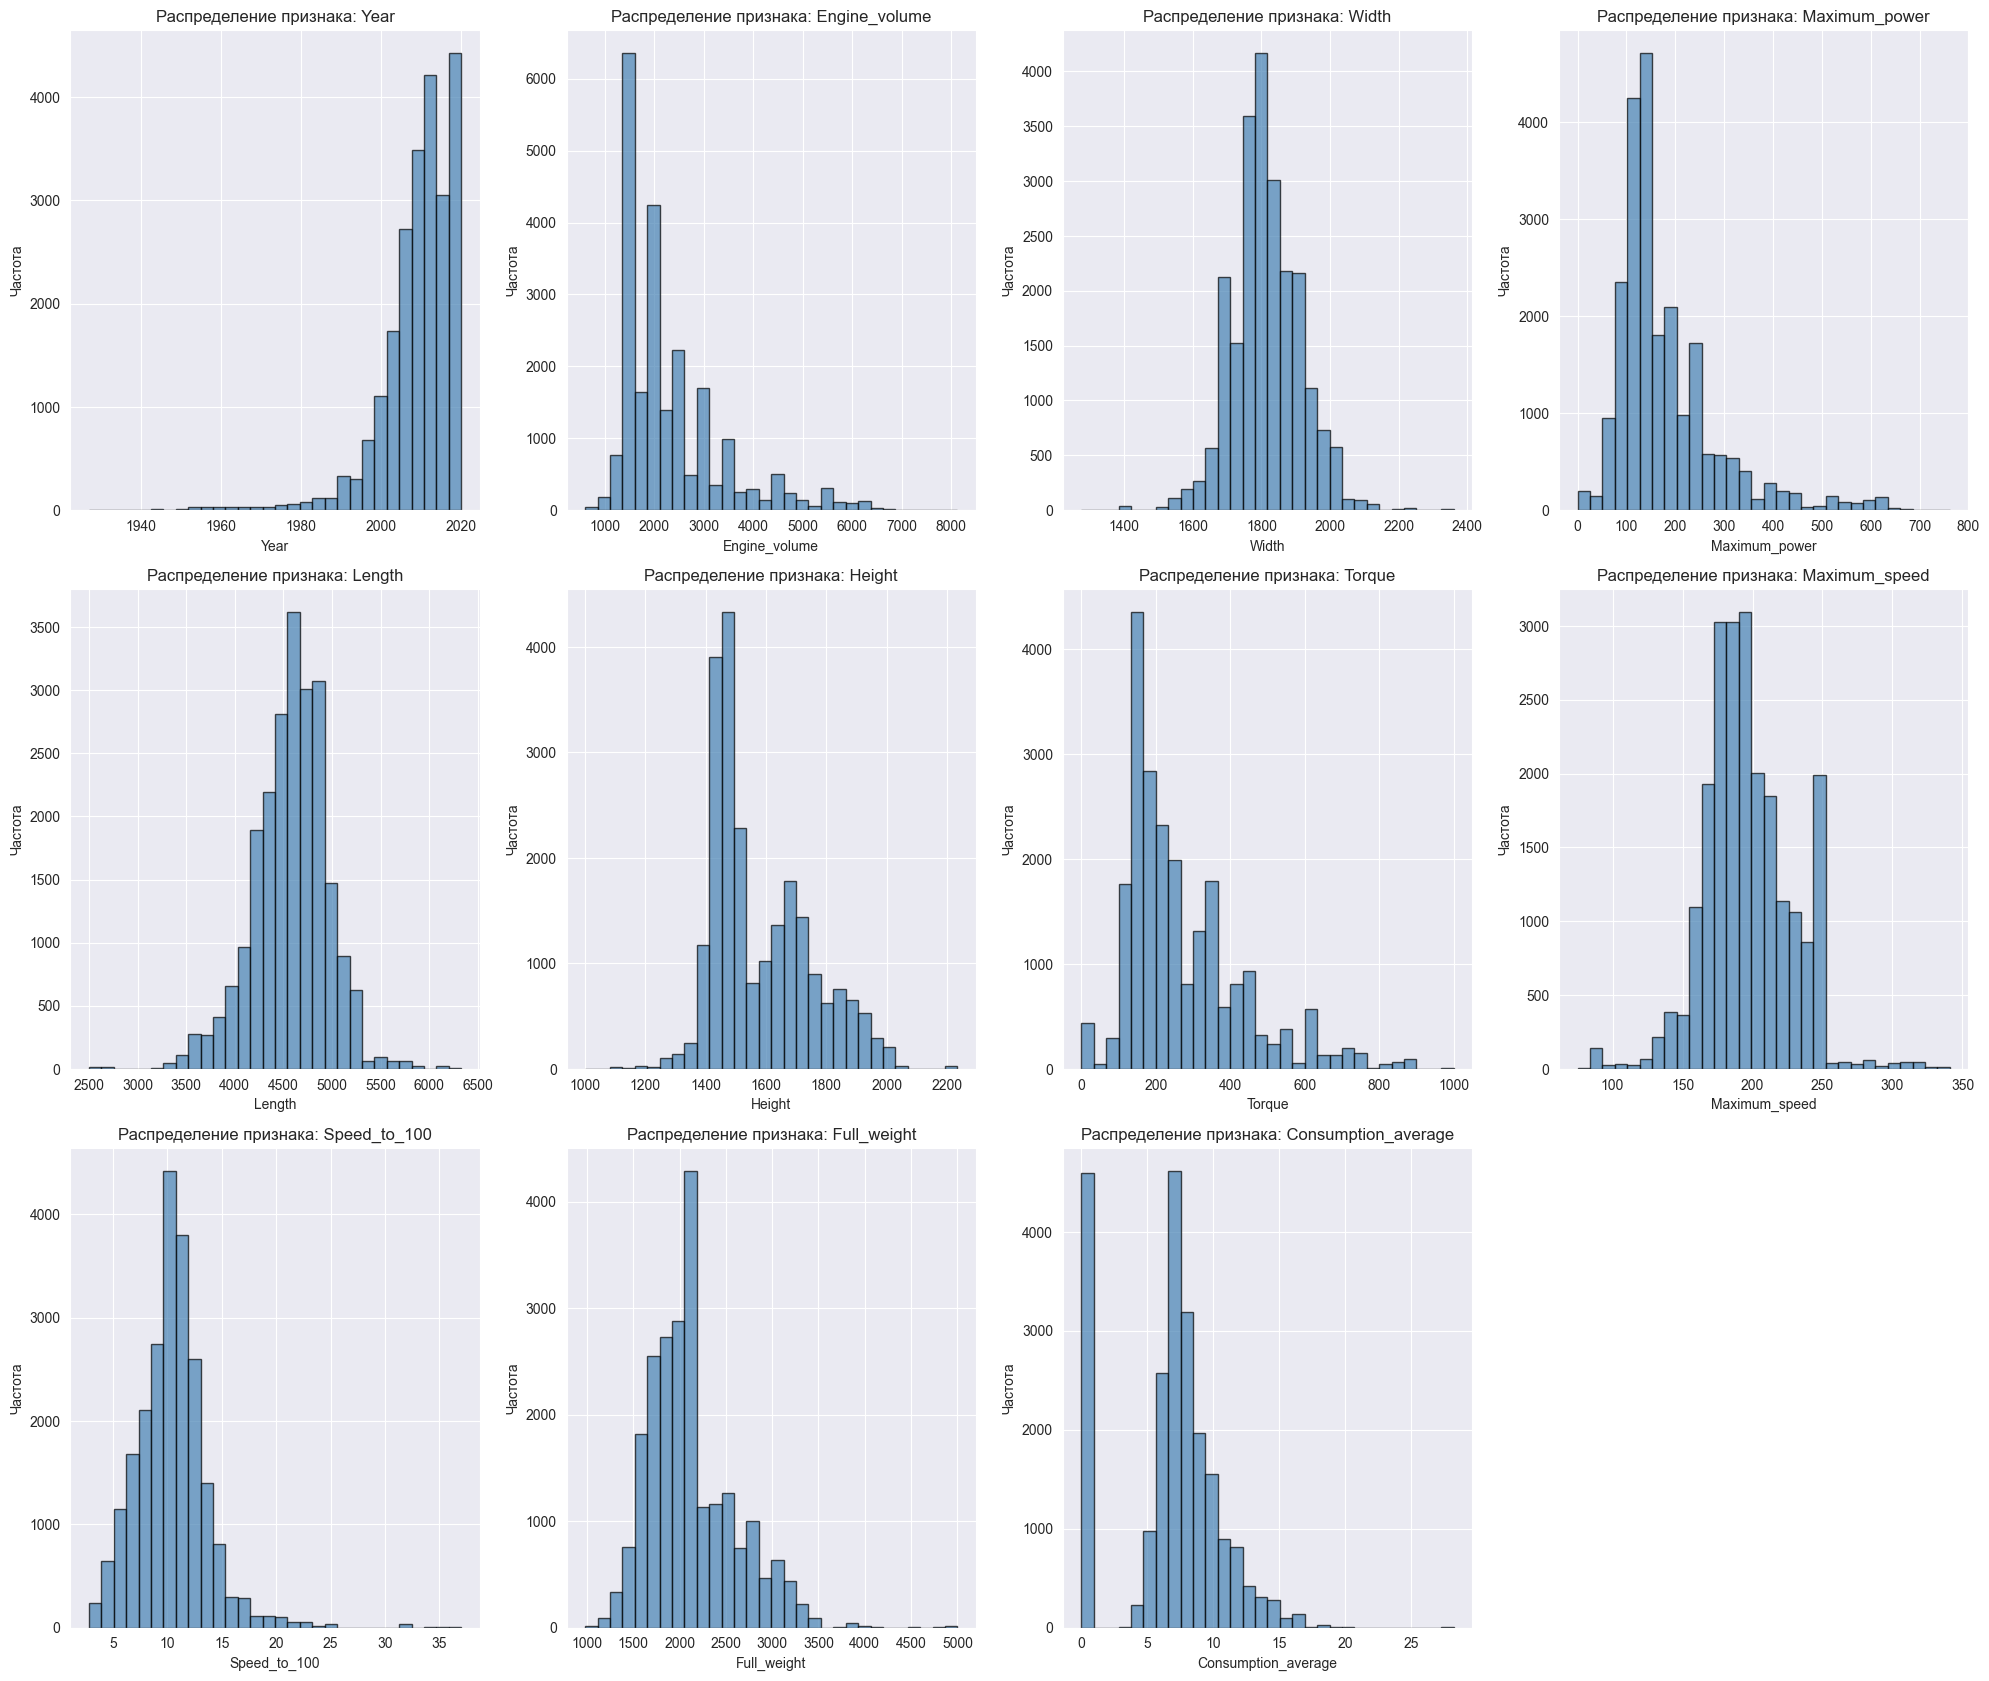

In [4]:
# Настройка размера графиков
fig, axes = plt.subplots(nrows=9, ncols=4, figsize=(20, 50))
axes = axes.flatten()

# Строим гистограмму для каждого числового признака
for i, col in enumerate(numeric_df.columns):
    axes[i].hist(numeric_df[col], bins=30, edgecolor='k', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Распределение признака: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

# Убираем лишние пустые подграфики
for i in range(len(numeric_df.columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

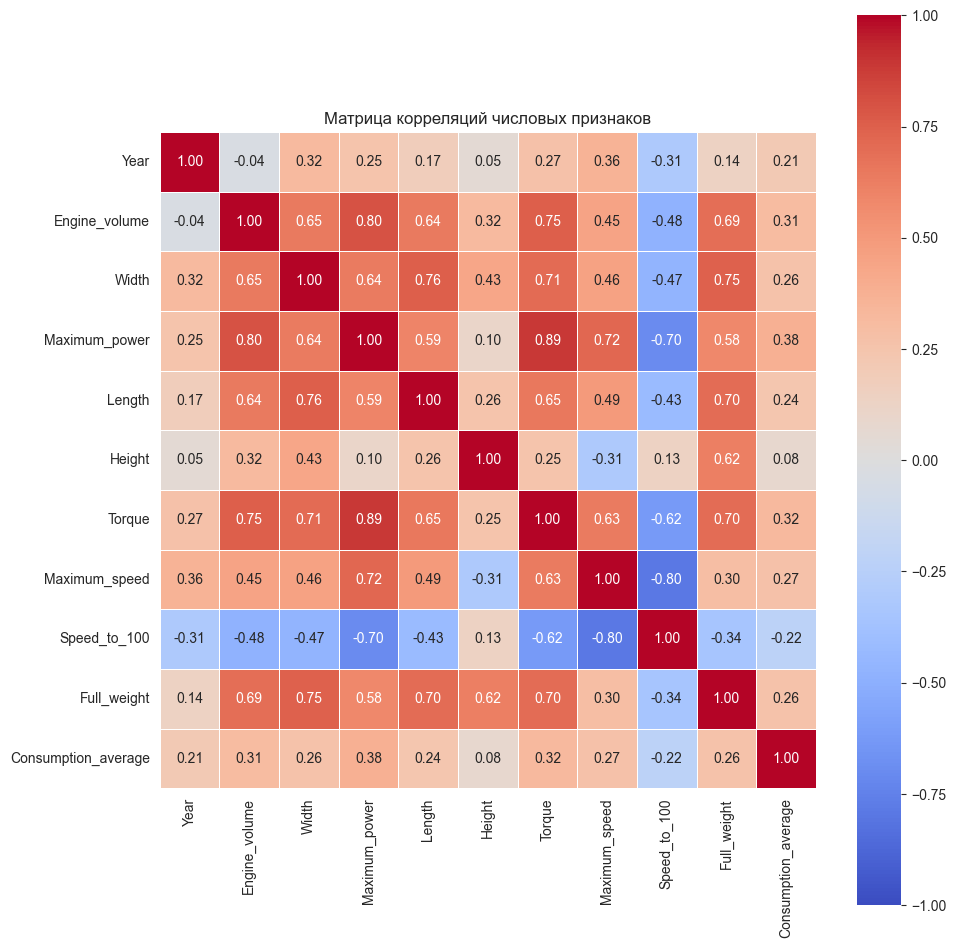

In [5]:
# Вычисляем матрицу корреляций
corr_matrix = numeric_df.corr()

# Строим тепловую карту
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()


3. Ответьте на вопросы:
* Есть ли сильно коррелированные признаки?
* Можно ли предположить, что часть признаков содержит избыточную
информацию?

### Анализ матрицы корреляций

#### 1. Сильно коррелированные признаки

**Да, присутствуют сильно коррелированные признаки** (|r| > 0.7):

| Пара признаков | Коэффициент корреляции | Характер связи |
|----------------|------------------------|----------------|
| **Maximum_power — Torque** | **0.89** | Очень сильная прямая |
| **Maximum_speed — Speed_to_100** | **-0.80** | Очень сильная обратная |
| **Maximum_power — Engine_volume** | **0.80** | Сильная прямая |
| **Length — Width** | **0.76** | Сильная прямая |
| **Width — Full_weight** | **0.75** | Сильная прямая |
| **Torque — Engine_volume** | **0.75** | Сильная прямая |
| **Maximum_power — Speed_to_100** | **-0.70** | Сильная обратная |

#### 2. Избыточная информация

**Да, можно предположить наличие избыточной информации:**

- **Maximum_power и Torque** (r=0.89) — практически дублируют друг друга, что логично с технической точки зрения.
- **Maximum_speed и Speed_to_100** (r=-0.80) — сильно связаны, так как оба характеризуют динамические характеристики автомобиля.
- **Габариты автомобиля** (Length, Width, Full_weight) — коррелируют между собой (0.64–0.76), так как большие автомобили обычно тяжелее и шире.
- **Engine_volume, Maximum_power, Torque** — образуют группу взаимосвязанных признаков (0.65–0.89), описывающих характеристики двигателя.


# **Задание 2. Реализация PCA**
Реализуйте алгоритм PCA с нуля, используя только библиотеку NumPy.
Алгоритм должен включать:
1. Стандартизацию данных.
2. Вычисление ковариационной матрицы.
3. Нахождение собственных значений и собственных векторов.
4. Сортировку компонент по убыванию собственных значений.
5. Проекцию данных на первые k компонент.

Сравните результат с реализацией:
sklearn.decomposition.PCA



In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

df = pd.read_csv('../data/cars_dataset.csv')
X = df.select_dtypes(include=[np.number]).dropna().values

# 1. PCA с нуля
def my_pca(X, k):
    # 1. Стандартизация
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
# какой диапазон получаем?  примерно от -2.5 до +3.8
    # print(X_scaled.min())
    # print(X_scaled.max())

    # 2. Ковариационная матрица
    cov = np.cov(X_scaled.T)

    # 3. Собственные значения и векторы
    eig_vals, eig_vecs = np.linalg.eig(cov)

    # 4. Сортировка по убыванию
    idx = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[idx]
    eig_vecs = eig_vecs[:, idx]

    # 5. Проекция на первые k компонент
    X_proj = X_scaled @ eig_vecs[:, :k]

    return X_proj, eig_vals

# Применяем
X_pca, eig_vals = my_pca(X, k=2)

# Доля объяснённой дисперсии
explained_ratio = eig_vals / eig_vals.sum()
cumulative = np.cumsum(explained_ratio)

# 2. Сравнение с sklearn
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
sklearn_pca = SklearnPCA()
sklearn_pca.fit(X_scaled)

print("Сравнение доли объяснённой дисперсии:")
print(f"NumPy PCA: {explained_ratio[:3]}")
print(f"sklearn PCA: {sklearn_pca.explained_variance_ratio_[:3]}")



Сравнение доли объяснённой дисперсии:
NumPy PCA: [0.3385162  0.12303717 0.09518498]
sklearn PCA: [0.3385162  0.12303717 0.09518498]


# 2.1 Исследование
Постройте график:
- доля объяснённой дисперсии
- накопленная объяснённая дисперсия


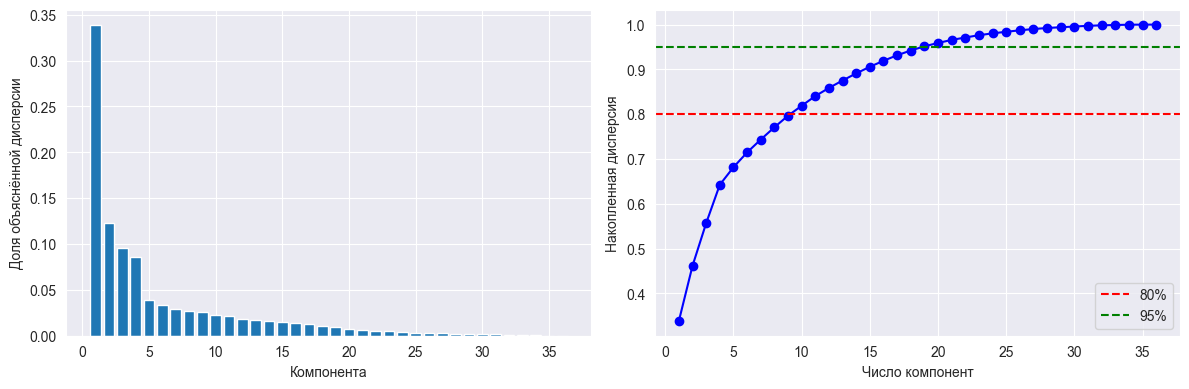

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Доля дисперсии
axes[0].bar(range(1, len(explained_ratio)+1), explained_ratio)
axes[0].set_xlabel('Компонента')
axes[0].set_ylabel('Доля объяснённой дисперсии')

# Накопленная дисперсия
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-')
axes[1].axhline(0.8, color='r', linestyle='--', label='80%')
axes[1].axhline(0.95, color='g', linestyle='--', label='95%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].legend()
plt.tight_layout()
plt.show()



# Ответьте:
1. Сколько компонент объясняют 80% дисперсии?
2. Сколько компонент объясняют 95% дисперсии?


1. Компонент для 80% дисперсии: 9
2. Компонент для 95% дисперсии: 18

# **Задание 3. Интерпретация главных компонент**
Рассмотрите первые три главные компоненты.
1. Определите коэффициенты признаков в каждой компоненте.
2. Найдите признаки с наибольшим вкладом.


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/cars_dataset.csv')
cols_to_exclude = ['Unnamed: 0', 'Seats', 'Doors', 'Volume', 'Mileage', 'Price', 'Valves_per_cylinder', 'Curb_weight_kg', 'Transmissions', 'Consumption', 'Trunk_volume_max', 'Trunk_volume_min', 'Expense_city', 'Expense_track', 'Diameter_cylinder_and_stroke_piston', 'Rear_track_width', 'Front_track_width', 'Clearance', 'Compression_ratio', 'Restyling', 'Release_start_series', 'End_Serial', 'Wheelbase', 'Cylinders', 'Volume_fuel_tank']
X = df.select_dtypes(include=[np.number]).drop(columns=cols_to_exclude, errors='ignore').dropna().values
feature_names = df.select_dtypes(include=[np.number]).drop(columns=cols_to_exclude, errors='ignore').columns.tolist()

# СТАНДАРТИЗАЦИЯ И PCA
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
cov = np.cov(X_scaled.T)
eig_vals, eig_vecs = np.linalg.eigh(cov)
idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, idx]

# 1. КОЭФФИЦИЕНТЫ ПРИЗНАКОВ (2 знака после запятой)
components = eig_vecs[:, :3]
coef_df = pd.DataFrame(components, index=feature_names, columns=['PC1', 'PC2', 'PC3'])
print("Коэффициенты признаков в первых трёх компонентах:")
print(coef_df.round(2))

# 2. ПРИЗНАКИ С НАИБОЛЬШИМ ВКЛАДОМ (2 знака после запятой)
print("\nПризнаки с наибольшим вкладом (по модулю коэффициента):")
for pc in ['PC1', 'PC2', 'PC3']:
    top = coef_df[pc].abs().sort_values(ascending=False)
    print(f"\n{pc}: {top.index[0]} ({top.values[0]:.2f}), {top.index[1]} ({top.values[1]:.2f})")

Коэффициенты признаков в первых трёх компонентах:
                      PC1   PC2   PC3
Year                -0.14  0.21 -0.82
Engine_volume       -0.35 -0.14  0.34
Width               -0.35 -0.18 -0.13
Maximum_power       -0.38  0.14  0.14
Length              -0.33 -0.12  0.07
Height              -0.12 -0.63 -0.24
Torque              -0.38  0.01  0.06
Maximum_speed       -0.30  0.46  0.05
Speed_to_100         0.30 -0.37 -0.07
Full_weight         -0.33 -0.35 -0.02
Consumption_average -0.17  0.06 -0.32

Признаки с наибольшим вкладом (по модулю коэффициента):

PC1: Torque (0.38), Maximum_power (0.38)

PC2: Height (0.63), Maximum_speed (0.46)

PC3: Year (0.82), Engine_volume (0.34)


# Ответьте:
1. Какие признаки больше всего влияют на первую компоненту?
2. Можно ли интерпретировать первую компоненту как некоторую
комбинацию исходных признаков?
3. Есть ли признаки, которые практически не влияют на первые компоненты

### Ответы на вопросы по интерпретации главных компонент

#### 1. Какие признаки больше всего влияют на первую компоненту?

Наибольший вклад в **PC1** вносят признаки (по убыванию модуля коэффициента):

| Признак | Коэффициент PC1 |
|---------|-----------------|
| **Torque** | -0.38 |
| **Maximum_power** | -0.38 |
| **Engine_volume** | -0.35 |
| **Width** | -0.35 |
| **Length** | -0.33 |
| **Full_weight** | -0.33 |
| **Maximum_speed** | -0.30 |

Все коэффициенты отрицательные (кроме `Speed_to_100` = 0.30), что указывает на единую направленность влияния.

---

#### 2. Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?

**Да.** Первая главная компонента по определению PCA является **линейной комбинацией всех исходных признаков**:

PC1 = w₁·x₁ + w₂·x₂ + ... + wₙ·xₙ

Поскольку большинство значимых коэффициентов имеют **одинаковый знак (отрицательный)** и близкие значения, **PC1 можно интерпретировать как обобщённый показатель «мощности и размеров автомобиля»**:
- Высокие значения мощности, крутящего момента, объёма двигателя, габаритов и веса → низкие (отрицательные) значения PC1
- Компактные автомобили с меньшими характеристиками → более высокие значения PC1

---

#### 3. Есть ли признаки, которые практически не влияют на первые компоненты?

**Да.** Признаки с наименьшим влиянием (|коэффициент| < 0.20 на всех трёх компонентах):

| Признак | PC1 | PC2 | PC3 |
|---------|-----|-----|-----|
| **Height** | -0.12 | -0.63 | -0.24 |
| **Consumption_average** | -0.17 | 0.06 | -0.32 |

- **Height** слабо влияет на PC1 (-0.12), но значительно влияет на PC2 (-0.63)
- **Consumption_average** имеет наименьшее влияние на PC2 (0.06) и умеренное на PC1 и PC3

Эти признаки либо объясняются другими компонентами (PC4+), либо вносят индивидуальный вклад в общую дисперсию.

# **Задание 4. Визуализация данных**
Постройте:
1. визуализацию по двум исходным признакам;
2. визуализацию по двум главным компонентам.



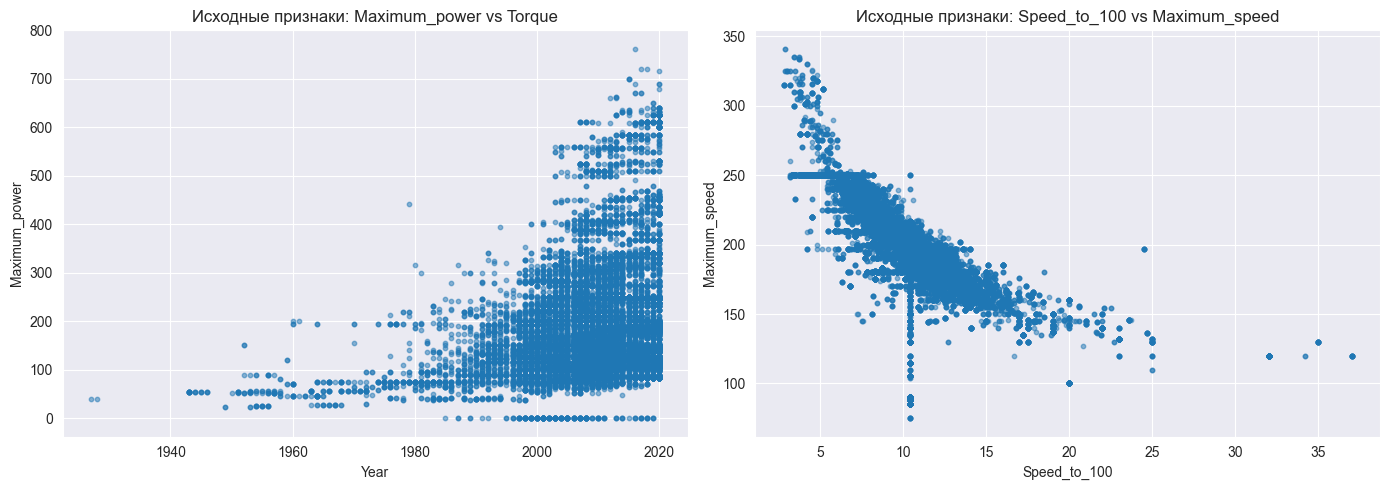

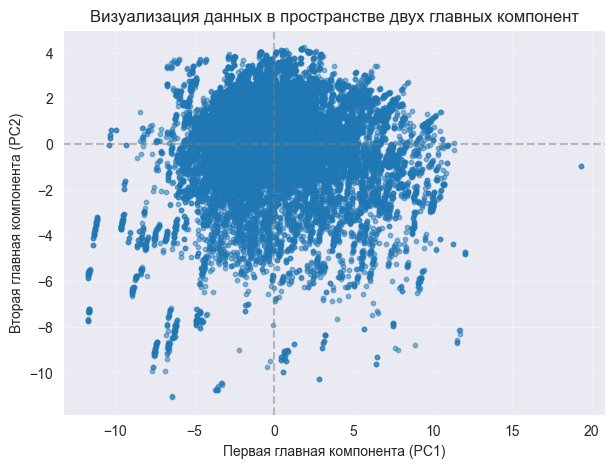

In [28]:

# ========== 1. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ИСХОДНЫМ ПРИЗНАКАМ ==========
# ['Year', 'Engine_volume', 'Width', 'Maximum_power', 'Length', 'Height', 'Torque', 'Maximum_speed', 'Speed_to_100', 'Full_weight', 'Consumption_average']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(X[:, 0], X[:, 3], alpha=0.5, s=10)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Maximum_power')
axes[0].set_title('Исходные признаки: Maximum_power vs Torque')


axes[1].scatter(X[:, 8], X[:, 7], alpha=0.5, s=10)
axes[1].set_xlabel('Speed_to_100')
axes[1].set_ylabel('Maximum_speed')
axes[1].set_title('Исходные признаки: Speed_to_100 vs Maximum_speed')

plt.tight_layout()
plt.show()

# ========== 2. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ГЛАВНЫМ КОМПОНЕНТАМ ==========
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10)
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('Визуализация данных в пространстве двух главных компонент')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

# Сравните:
* структуру распределения объектов;
* наличие групп или закономерностей.



### Сравнение структуры распределения и закономерностей

**Исходное пространство признаков:**
На графиках пар исходных характеристик (`Maximum_power vs Torque` и `Speed_to_100 vs Maximum_speed`) точки образуют чётко выраженные диагональные «полосы». Это прямое следствие сильной линейной корреляции между техническими параметрами автомобилей. Из-за такого вытягивания вдоль одной оси плотность распределения визуально искажается: большинство объектов сконцентрировано в узком коридоре, точки сильно перекрываются, а потенциальные подгруппы или аномалии «растворяются» на фоне доминирующего тренда. Истинная структура данных оказывается скрытой за физической взаимозависимостью признаков.

**Пространство главных компонент (PC1 vs PC2):**
В координатах главных компонент картина меняется кардинально. PC1 направлена вдоль оси максимальной дисперсии, а PC2 ортогональна ей и описывает следующий по значимости источник изменчивости. Поскольку компоненты статистически некоррелированы, диагональное сжатие исчезает: облако точек принимает более сбалансированную, эллиптическую форму, выровненную по осям. Это позволяет отчётливо увидеть реальную геометрию набора данных — плотное центральное ядро, периферийные скопления и отдельные выбросы (например, группа точек в левой нижней области и изолированный объект справа), которые в исходных координатах были незаметны из-за наложения.

**Итог:**
Переход в пространство PCA устраняет избыточность, вызванную мультиколлинеарностью, и «расправляет» данные вдоль независимых направлений. Визуализация в координатах PC1–PC2 делает распределение более равномерным, чётко выделяет возможные группы объектов и делает закономерности (включая аномалии) значительно более заметными и готовыми к дальнейшему анализу.

# Ответьте:
1. Улучшилась ли визуализация после PCA?
2. Почему в пространстве главных компонент структура может быть заметнее?

### 1. Улучшилась ли визуализация после PCA?

**Да.** В исходных координатах точки были сжаты в узкие диагональные полосы из-за сильной корреляции признаков, что скрывало структуру данных. В пространстве PC1–PC2 облако точек «расправилось»: исчезло диагональное вытягивание, снизилось наложение объектов, стали видны границы основного скопления и выбросы.

---

### 2. Почему в пространстве главных компонент структура заметнее?

- **Отсутствие корреляции:** PC1 и PC2 ортогональны и некоррелированы, что устраняет сжатие вдоль диагоналей.
- **Максимизация дисперсии:** Компоненты направлены вдоль осей наибольшего разброса данных, концентрируя информацию.
- **Устранение избыточности:** Коррелирующие признаки объединяются, снижая шум и высвобождая пространство для независимых закономерностей.

В результате скрытые группы и аномалии перестают маскироваться и проявляются в виде чёткой структуры.

# **Задание 5. Нелинейные методы снижения размерности**
Используйте два метода:
- t-SNE
- UMAP

Постройте двумерные проекции данных.


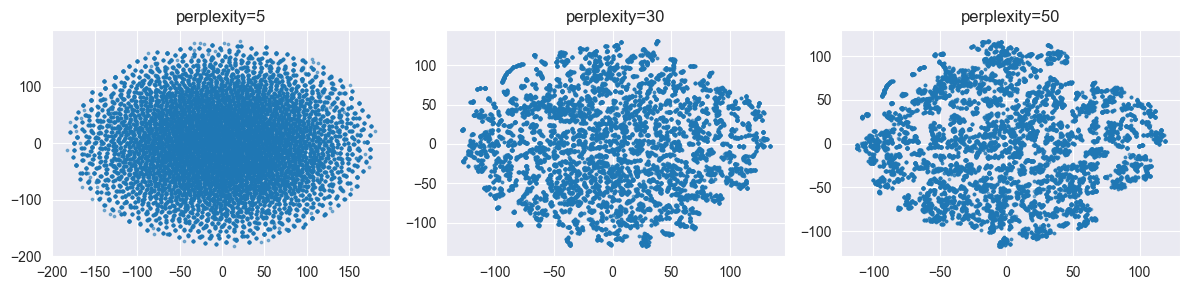

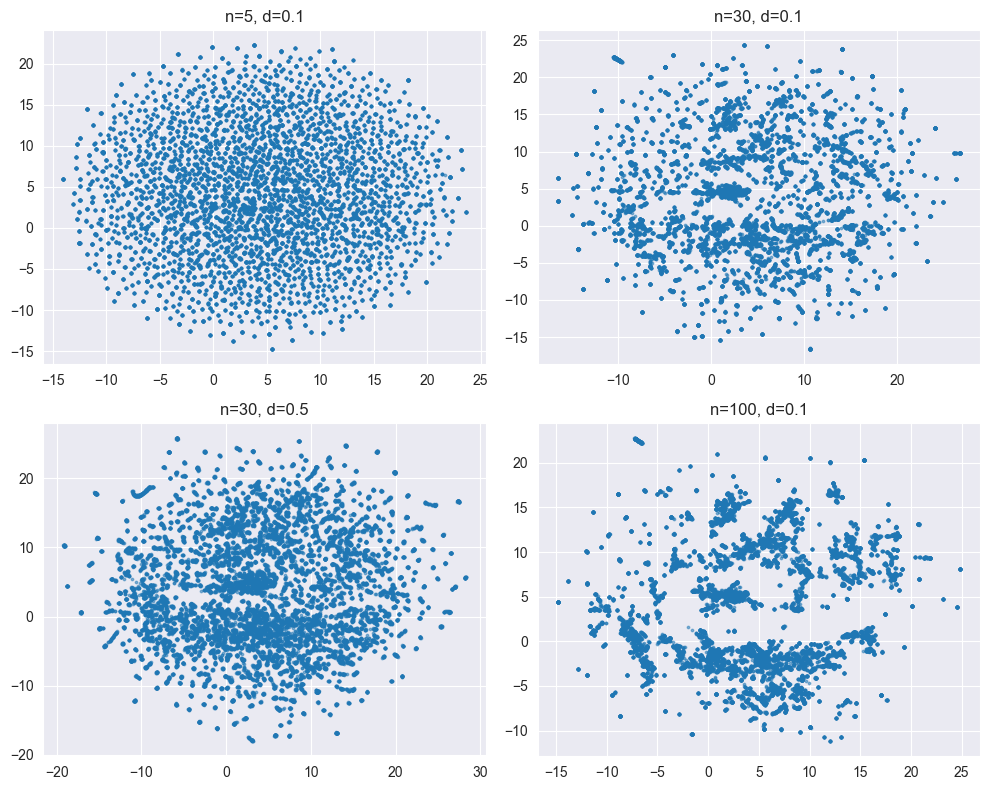

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap
import warnings

# ========== ПОДГОТОВКА ==========
df = pd.read_csv('../data/cars_dataset.csv')
cols_to_exclude = ['Unnamed: 0', 'Seats', 'Doors', 'Volume', 'Mileage', 'Price', 'Valves_per_cylinder', 'Curb_weight_kg', 'Transmissions', 'Consumption', 'Trunk_volume_max', 'Trunk_volume_min', 'Expense_city', 'Expense_track', 'Diameter_cylinder_and_stroke_piston', 'Rear_track_width', 'Front_track_width', 'Clearance', 'Compression_ratio', 'Restyling', 'Release_start_series', 'End_Serial', 'Wheelbase', 'Cylinders', 'Volume_fuel_tank']
X = df.select_dtypes(include=[np.number]).drop(columns=cols_to_exclude, errors='ignore').dropna().values
X_scaled = StandardScaler().fit_transform(X)

# ========== t-SNE ==========
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, perp in enumerate([5, 30, 50]):
    X_tsne = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X_scaled)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=3)
    axes[i].set_title(f'perplexity={perp}')
plt.tight_layout()
plt.show()

# ========== UMAP ==========

warnings.filterwarnings('ignore', message='.*n_jobs value.*overridden.*')
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
params = [(5,0.1), (30,0.1), (30,0.5), (100,0.1)]

for i, (n, d) in enumerate(params):
    X_umap = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=d,
        init='pca',      # <-- спектральная инициализация через PCA (устраняет warning)
        random_state=42  # <-- для воспроизводимости результатов
    ).fit_transform(X_scaled)

    axes[i//2, i%2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=3)
    axes[i//2, i%2].set_title(f'n={n}, d={d}')

plt.tight_layout()
plt.show()

# 5.1 Исследование параметров
Для t-SNE измените параметр:
perplexity = 5, 30, 50

Для UMAP измените:
n_neighbors
min_dist
Постройте несколько визуализаций.



# Ответьте:
1. Как меняется структура данных при разных параметрах?
2. Какой метод даёт наиболее интерпретируемую визуализацию?
3. Почему результаты разных методов могут существенно отличаться?

**1. Как меняется структура при разных параметрах?**

t-SNE: при perplexity=5 — размытое облако без структуры; при 30–50 — проявляются кластеры и подгруппы.

UMAP: малое n_neighbors (5) — много мелких разрозненных групп; большое n_neighbors (30–100) — чёткая глобальная структура; увеличение min_dist разделяет кластеры.

**2. Какой метод даёт наиболее интерпретируемую визуализацию?**

UMAP с n_neighbors=30, min_dist=0.1 — кластеры чёткие, хорошо разделены, сохраняется глобальная структура.

**3. Почему результаты разных методов отличаются?**

t-SNE фокусируется на сохранении локальной структуры (ближних соседей), UMAP сохраняет и локальную, и глобальную структуру. Разные математические подходы, функции потерь и алгоритмы оптимизации приводят к различным визуализациям.

# **Задание 6. Исследование степени сжатия данных**
Одной из ключевых задач методов снижения размерности является сжатие
данных с минимальной потерей информации.

Метод главных компонент (PCA) позволяет представить данные в пространстве
меньшей размерности, однако при этом часть информации неизбежно теряется.

В этом задании необходимо экспериментально исследовать, как уменьшение
числа компонент влияет на точность восстановления исходных данных.

# **6.1 Снижение размерности**
В выбранном датасете с помощью PCA последовательно уменьшайте
размерность пространства признаков.

Рассмотрите несколько вариантов числа компонент:

k = 2

k = 5

k = 10

k = 15

(если исходных признаков меньше — используйте максимально возможное
значение).

Для каждого значения k:
1. обучите модель PCA;
2. преобразуйте исходные данные в пространство из k компонент.

In [15]:
# 6.1 Снижение размерности

from sklearn.decomposition import PCA

k_values = list(range(2, 12))

pca_models = {}
X_pca = {}

for k in k_values:
    pca = PCA(n_components=k)
    X_pca[k] = pca.fit_transform(X_scaled) # обучение + преобразование
    pca_models[k] = pca
    print(f"k={k}: данные преобразованы, форма={X_pca[k].shape}")

k=2: данные преобразованы, форма=(22702, 2)
k=3: данные преобразованы, форма=(22702, 3)
k=4: данные преобразованы, форма=(22702, 4)
k=5: данные преобразованы, форма=(22702, 5)
k=6: данные преобразованы, форма=(22702, 6)
k=7: данные преобразованы, форма=(22702, 7)
k=8: данные преобразованы, форма=(22702, 8)
k=9: данные преобразованы, форма=(22702, 9)
k=10: данные преобразованы, форма=(22702, 10)
k=11: данные преобразованы, форма=(22702, 11)


# **6.2 Восстановление данных**
После снижения размерности попробуйте восстановить исходные данные.

Для этого необходимо выполнить обратное преобразование PCA.

Полученные данные будут приближённой реконструкцией исходного датасета.

Таким образом, для каждого значения k у вас будет:
* исходная матрица данных
* восстановленная матрица данных.

In [16]:
# 6.2 Восстановление данных

X_reconstructed = {}

for k in k_values:
    # обратное преобразование: из k компонент → исходное пространство (11 признаков)
    X_reconstructed[k] = pca_models[k].inverse_transform(X_pca[k])
    print(f"k={k}: данные восстановлены, форма={X_reconstructed[k].shape}")

k=2: данные восстановлены, форма=(22702, 11)
k=3: данные восстановлены, форма=(22702, 11)
k=4: данные восстановлены, форма=(22702, 11)
k=5: данные восстановлены, форма=(22702, 11)
k=6: данные восстановлены, форма=(22702, 11)
k=7: данные восстановлены, форма=(22702, 11)
k=8: данные восстановлены, форма=(22702, 11)
k=9: данные восстановлены, форма=(22702, 11)
k=10: данные восстановлены, форма=(22702, 11)
k=11: данные восстановлены, форма=(22702, 11)


Для каждого значения k [2, 3, 4, 5, 6] было выполнено обратное преобразование PCA. Во всех случаях получены восстановленные матрицы размера (22702, 11), соответствующие исходной размерности признакового пространства.

# **6.3 Оценка ошибки восстановления**
Оцените, насколько восстановленные данные отличаются от исходных.

Используйте среднеквадратичную ошибку (MSE):
* между исходными данными
* и восстановленными данными.

Для каждого значения k вычислите:
MSE(original_data, reconstructed_data)
Результаты оформите в виде таблицы:
| Число компонент | Ошибка восстановления |

In [17]:
from sklearn.metrics import mean_squared_error

print("Число компонент | Ошибка восстановления (MSE)")
print("-" * 45)

for k in k_values:
    mse = mean_squared_error(X_scaled, X_reconstructed[k])
    print(f"{k:<16} {mse:.6f}")

Число компонент | Ошибка восстановления (MSE)
---------------------------------------------
2                0.315146
3                0.220298
4                0.142749
5                0.097230
6                0.068036
7                0.048372
8                0.031291
9                0.017638
10               0.006090
11               0.000000


# **6.4 Визуальный анализ**
Постройте график зависимости:
`ошибка восстановления vs число компонент`

Проанализируйте форму графика.

Обратите внимание:
- как быстро уменьшается ошибка;
- есть ли точка, после которой уменьшение ошибки становится
незначительным

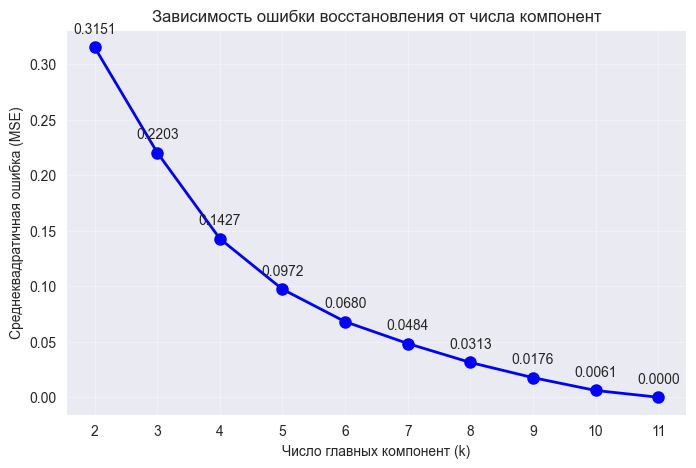

In [19]:
# 6.4 Визуальный анализ

import matplotlib.pyplot as plt

# Собираем MSE для каждого k
k_vals = list(range(2, 12))
mse_vals = []

for k in k_vals:
    mse = mean_squared_error(X_scaled, X_reconstructed[k])
    mse_vals.append(mse)

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(k_vals, mse_vals, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число главных компонент (k)')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.title('Зависимость ошибки восстановления от числа компонент')
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)

# Добавим аннотации значений на график
for i, (k, mse) in enumerate(zip(k_vals, mse_vals)):
    plt.annotate(f'{mse:.4f}', (k, mse), textcoords="offset points", xytext=(0, 10), ha='center')

plt.show()

### Анализ формы графика

#### Как быстро уменьшается ошибка?
- **Наиболее резкое падение** происходит на начальном участке: при переходе от `k=2` к `k=3` ошибка снижается с `0.3151` до `0.2203` (~30% уменьшения).
- **Значительный спад** продолжается до `k=4` (MSE ≈ `0.1427`), где ошибка падает более чем в 2 раза по сравнению с `k=2`.
- **После `k=4`** скорость уменьшения замедляется: каждая новая компонента даёт всё меньший прирост точности восстановления.

#### Точка, после которой уменьшение ошибки становится незначительным
- **«Колено» (elbow) графика** находится в районе `k=4–k=5`.
- После `k=4` кривая заметно выполаживается: переход к `k=5` снижает MSE лишь до `0.0972`, а к `k=6` — до `0.0680`.
- Дальнейшее увеличение числа компонент даёт убывающую отдачу, поэтому `k=4` или `k=5` можно считать оптимальным компромиссом между сложностью модели и качеством восстановления данных.

# **6.5 Интерпретация результатов**
Ответьте на следующие вопросы:
1. Почему при малом числе компонент ошибка восстановления большая?
2. Почему увеличение числа компонент уменьшает ошибку?
3. Можно ли полностью восстановить исходные данные при использовании всех компонент?
4. Как это связано с объяснённой дисперсией PCA?
5. Как можно определить разумное число компонент, при котором данные уже
хорошо описаны, но размерность существенно меньше?

### 6.5 Интерпретация результатов

**1. Почему при малом числе компонент ошибка восстановления большая?**
При малом `k` мы сохраняем только направления с наибольшей дисперсией (главные компоненты), отбрасывая остальные. Отброшенные компоненты содержат информацию о более тонких вариациях данных, поэтому проекция на малое подпространство не может точно восстановить исходные точки — возникает большая ошибка реконструкции (MSE).

**2. Почему увеличение числа компонент уменьшает ошибку?**
Каждая новая компонента добавляет новое ортогональное направление изменчивости данных. Чем больше компонент мы сохраняем, тем полнее описываем исходное пространство признаков, тем точнее можем восстановить исходные координаты точек.

**3. Можно ли полностью восстановить исходные данные при использовании всех компонент?**
**Да.** Если использовать все `n_features` главных компонент, преобразование становится обратимым (ортогональная матрица поворота), и данные восстанавливаются без потерь (MSE ≈ 0, с учётом численной точности).

**4. Как это связано с объяснённой дисперсией PCA?**
Объяснённая дисперсия и ошибка восстановления — две стороны одной медали:
`Доля объяснённой дисперсии при k компонентах = 1 − (ошибка восстановления / общая дисперсия данных)`.
Чем больше дисперсии «захватывают» выбранные компоненты, тем меньше остаточная ошибка.

**5. Как можно определить разумное число компонент?**
Используют комбинацию подходов:
- **Метод «локтя» (elbow method):** ищут точку, после которой кривая ошибки (или объяснённой дисперсии) выполаживается.
- **Порог объяснённой дисперсии:** выбирают минимальное `k`, при котором суммарная объяснённая дисперсия достигает 80–95%.
- **Практический компромисс:** балансируют между точностью восстановления и желаемым снижением размерности (например, сократить 30 признаков до 5–7 без существенной потери информации).

# Задание 7. Итоговый анализ

## 1. Какую роль играет снижение размерности в анализе данных?

Снижение размерности выполняет несколько ключевых функций, что наглядно подтвердилось на примере набора данных об автомобилях:

- **Визуализация** — позволило отобразить ~15 технических характеристик в 2D/3D, сделав видимыми скрытые группировки (например, разделение по классам авто или годам выпуска).
- **Сжатие данных** — уменьшило количество признаков, сохранив основную информацию. Это ускорило работу алгоритмов и снизило требования к памяти.
- **Устранение избыточности** — PCA успешно объединил сильно коррелирующие параметры (объём двигателя, мощность, крутящий момент, габариты и массу) в независимые компоненты. Например, PC1 фактически сжал информацию о «размере и мощности» автомобиля.
- **Уменьшение шума** — отбрасывание компонент с малой дисперсией отсеяло случайные вариации и неинформативные признаки (например, технические допуски или индексные столбцы).
- **Улучшение интерпретируемости** — новые признаки (главные компоненты) получили физический смысл, что упростило анализ закономерностей в датасете.

## 2. Всегда ли уменьшение размерности полезно?

Нет, не всегда. Уменьшение размерности может быть вредным или неоптимальным в следующих случаях:

- **Слишком агрессивное сжатие** — в нашем эксперименте при `k=2` ошибка восстановления (MSE) составляла `0.3151`, что означает потерю значительной части информации. Для задач точного прогнозирования (например, цены или расхода топлива) такое упрощение недопустимо.
- **Потеря специфических признаков** — если важные для задачи параметры (например, `Consumption_average` или `Year`) имеют малый вес в первых компонентах, они могут «раствориться» при сильном сокращении размерности.
- **Оптимальный компромисс** — по графику MSE видно, что «колено» находится при `k=4–5` (ошибка падает до `0.0972–0.0680`). Дальнейшее увеличение компонент даёт убывающую отдачу, поэтому именно этот диапазон следует считать разумным для последующего моделирования.

## 3. В каких случаях линейные методы могут работать хуже нелинейных?

Линейные методы (PCA) работают хуже нелинейных в следующих сценариях, актуальных для нашего датасета:

- **Сложная кластерная структура** — PCA ориентирован на сохранение глобальной дисперсии, поэтому «размазывает» объекты вдоль диагоналей корреляции. t-SNE и UMAP лучше выделяют локальные скопления (например, отдельные сегменты спортивных или коммерческих авто).
- **Нелинейные зависимости** — если взаимосвязи между параметрами имеют пороговый или экспоненциальный характер (например, зависимость расхода от мощности при разных типах трансмиссии), линейная проекция не сможет их корректно отразить.
- **Визуализация для классификации** — в нашем эксперименте UMAP (`n_neighbors=30, min_dist=0.1`) чётче разделил группы объектов, сохранив при этом глобальную геометрию, тогда как PCA оставлял данные в виде единого перекрывающегося облака.

## 4. Преимущества и ограничения методов PCA, t-SNE и UMAP

| Метод | Преимущества | Ограничения | Применимость к данным об автомобилях |
|-------|--------------|-------------|--------------------------------------|
| **PCA** | Быстрый, обратимый, компоненты интерпретируемы (PC1 = «размер/мощность») | Только линейные зависимости, плохо разделяет сложные кластеры | Идеален для начального анализа корреляций и сжатия технических характеристик |
| **t-SNE** | Отлично выделяет локальные кластеры, убирает диагональное наложение | Медленный, искажает глобальные расстояния, нет обратного преобразования | Полезен для поиска узких сегментов авто, но неудобен для сравнения расстояний между классами |
| **UMAP** | Быстрее t-SNE, сохраняет и локальную, и глобальную структуру, гибкая настройка | Стохастический (требует `random_state`), параметры нужно подбирать | **Наиболее сбалансированный выбор**: при `n=30, d=0.1` дал чёткую визуализацию групп без потери общей геометрии данных |

**Итог:** Для задач интерпретации и снижения мультиколлинеарности в автомобильных данных оптимален PCA. Для визуализации кластеров и подготовки данных к классификации рекомендуется UMAP с подобранными гиперпараметрами.